PINN Example: One-dimensional Burgers' Equation
===

Summary:
---

---

This example is taken from Maziar Raissi's example [here](https://maziarraissi.github.io/PINNs/). It will demonstrate most of the key points in his paper, found [here](https://www.sciencedirect.com/science/article/pii/S0021999118307125#se0140).

The aim is to find solutions to parametrized and nonlinear partial differential equations of the general form:

$$
\partial u_t + \mathcal{N}[u; \vec{\lambda}] = 0,
$$

where $x \in \Omega$ and $t \in [0, T]$. Here, $u(x, t)$ denotes the latent (hidden) solution, $\mathcal{N}[u; \vec{\lambda}]$ is a nonlinear operator parametrized by $\vec{\lambda}$, and $\Omega$ is a subset of $\mathbb{R}^D$.


> 🤔 The basic idea of a PINN is to treat the divergence from the equation above, plus deviation from set initial and boundary conditions, as the loss function we are going to minimize.  The loss function of a conventional neural network is just the deviation between some observed training data and its predictions at the same points.  Here, we instead enforce consistency with known physical laws to make the network behave like a conventional solution to such a PDE.  If we posit a form, $\mathcal{N}$, and set of parameters, $\vec{\lambda}$, we don't need any training data!  If we do not know these, but we do have training data, we can learn / discover the parameters of the PDE itself!

We will start with a simple partial differential equation and explore how we can (1) solve the equation and (2) also discover it to begin with.  The [one-dimensional Burgers' equation](https://en.wikipedia.org/wiki/Burgers%27_equation) we will use in this example is:

$$
\partial u_t + u \partial u_x = \nu \partial^2_xu,
$$

where $u(x, t)$ is a flow field. In this example, $\mathcal{N}[u; \vec{\lambda}] = \lambda_1 u \partial u_x - \lambda_2 \partial^2_xu$ where $\lambda_1 = 1$ and $\lambda_2 = \nu$. The kinematic viscosity, $\nu$, can be set by the user, if known; otherwise, if training data is available, we can instead use this to fit $\nu$ itself. In the following examples the field's initial condition is:

$$
u(x, t=0) = - {\rm sin}(\pi x),
$$

and we have 2 Dirichlet boundary conditions:

$$
u(x=+1, t) = u(x=-1, t) = 0.
$$

The bounds of the problem are constrained to: $ t \in [0, 1], x \in [−1, 1]$. We will use $\nu = \lambda_2 = 0.01/\pi \sim 0.00318$, but you can change this if you like.

👉 This is a useful minimal example since this equation with this value of $\nu$ leads to a discontinuous shock, and is therefore non-trivial to solve.

The PINN we are going to create looks something like this:

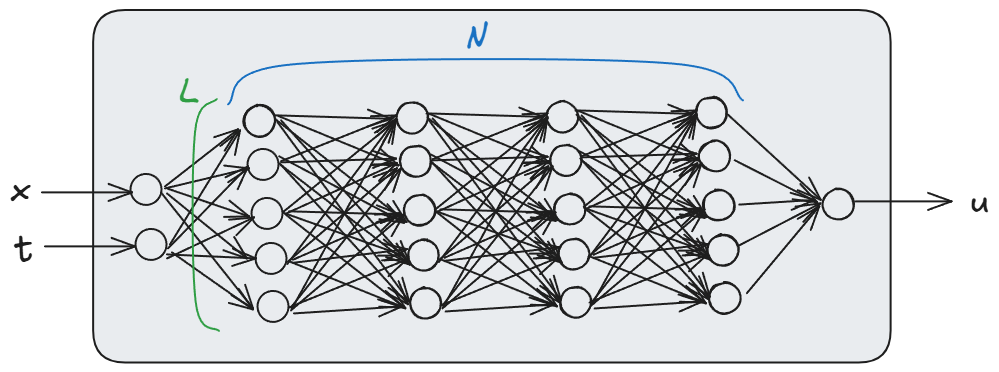

Key Points
---

---

1. We first illustrate fitting a scalar field, $u$, to 2 inputs, $(x, t)$, for a continuous time model. This allows us to obtain a neural net that approximates $u(x, t)$ when we know the IC and BC(s) and just want to solve a PDE (or ODE).

2. Here we will use the [Adam](https://arxiv.org/pdf/1412.6980) optimizer to fit the neural network, which is commonly used tool in deep learning. However, the original paper employed an alternative loss minimization strategy using the L-BFGS method.  In general, we find the Adam optimizer to be faster and more efficient.

3. We then show how to obtain coefficients in this governing equation by using training data ("PDE discovery").  In this case, we will not assume any ICs or BC, and simply fit to measured (simulated) data.  With this method, measured data can be used to directly infer physical constants like kinematic viscosity, in this example.

4. Consider using a [normalization layer](https://keras.io/api/layers/preprocessing_layers/numerical/normalization/) to help training.  Also, it is best to work with non-dimensionalized equations when possible for stability reasons.

⚠ In principle, training should be halted based on when the loss measured on a held-out validation set; this is not done here, though it is not difficult to implement.  For illustration purposes the approach used below is sufficient.

👉 It is important to use a network that is expressive enough to effectively represent the solution, however, this is not easy to know in advance. Here, we will use a very simple NN architecture of N layers each with a width of L.  I recommend starting with a small number of layers (all of width, L) and progressively adding more layers to see if the loss systematically plateaus to a lower value over time.  You can start with L ~ 20-100, but adjust as needed. In practice, this architecture (and the learning rate) should be optimized as adjustable hyperparameters using an external validation set.

In [ ]:
import os
import tqdm
import torch

import torch.nn as nn
import numpy as np
import plotly.graph_objects as go
import scipy.io as sio

from numpy.typing import NDArray
from plotly.subplots import make_subplots
from pyDOE import lhs
from typing import Union, Any, ClassVar

In [ ]:
%load_ext watermark
%watermark -t -m -v --iversions

# 1. Inference: Solving the PDE with IC and BCs

First, we are going to solve the PDE like we would on paper using analytical methods.  We start from the boundary conditions, initial condition, and PDE itself and try to come up with an answer.  Here, the "answer" is a neural net trained to follow the PDE and its constraints.  We will first need to generate BC and IC points by selecting (randomly, with latin-hypercube, or other method) points to use where agreement will be assessed.  We similarly need to choose ("collocation") points in the [x, t] space to assess how well the function obeys the PDE there.  This agreement can be done easily through the magic of [automatic differentiation](https://en.wikipedia.org/wiki/Automatic_differentiation) which is used in training neural networks already.  

👉 In this case, we do not need any training data - just the same information we would have if we tried to solve this with pencil and paper!

In [ ]:
# For reproducibility, let's set these seeds
np.random.seed(1234)
_ = torch.manual_seed(0)

## Create the ICs and BCs and choose collocation points

In [ ]:
N_0 = 100 # Number of initial condition points to use
N_b = 100 # Number of boundary points to use
N_f = 10000 # Number of measured psi(x, t) training points to use

lb = np.array([-1.0, 0.0]) # [x_min, t_min]
ub = np.array([1.0, 1.0]) # [x_max, t_max]

# Select random (latin-hypercube sampling) x positions to use at t = 0
x_0 = lhs(1, N_0)*(ub[0] - lb[0]) + lb[0]
X_0 = np.hstack((x_0, np.array([[lb[1]]]*len(x_0))))
u_0 = -np.sin(np.pi*x_0)

# Select random (latin-hypercube sampling) time points to use along x-boundaries. In principle, the t values along x = -1 edge do not need to be the same as along the x = +1 edge, but we will use the same ones here for simplicity.
t_b = lhs(1, N_b)*(ub[1] - lb[1]) + lb[1]
X_b = np.vstack(
    (
        np.hstack((np.array([[lb[0]]]*len(t_b)), t_b)),
        np.hstack((np.array([[ub[0]]]*len(t_b)), t_b))
    )
)
u_b = np.array([[0.0]]*len(X_b))

# Use latin-hypercube sampling to get a random sampling of (x, t) "collocation" points we will predict / measure the fitted neural net against.
X_f = lb + (ub-lb)*lhs(2, N_f) # "Interior" (x, t) points

## Solve

❗ Key points and good practices for solving these PINNs are provided in the comments below.  Read the code to understand what is happening.

In [ ]:
import mlflow

# If you are not using the Docker devcontainer you might need to point to your MLFlow server
# The start_jupyter.sh automatically sets the MLFLOW_TRACKING_URI to match the start_mlflow.sh script
# mlflow.set_tracking_uri('http://127.0.0.1:4342') 

In [ ]:
class Model(nn.Module):
    """
    Fully connected neural network that acts as the surrogate function.
    """
    model: ClassVar[nn.Module]
    
    def __init__(self, inputs: int, outputs: int, layers: list[int], activation: str = 'Tanh', dtype: torch.dtype = torch.float32) -> None:
        """
        Instantiate the neural network.

        Parameters
        ----------
        inputs : int
            Number of inputs to the model.

        outputs : int
            Number of outputs from the model.
            
        layers : list(int)
            An ordered list of the size of each dense layer in the network to create.

        activation : str, optional(default='Tanh')
            Activation function (by name) to use in each layer.
            
        dtype : torch.dtype, optional(default=torch.float32)
            Precision to train neural net with.
        """
        super().__init__()
        setattr(self, "layers", layers)

        seq = [nn.Linear(in_features=inputs, out_features=layers[0], dtype=dtype), getattr(nn, activation)() ]
        for i in range(1, len(layers)):
            seq += [nn.Linear(in_features=layers[i-1], out_features=layers[i], dtype=dtype), getattr(nn, activation)() ]
        seq += [nn.Linear(in_features=layers[-1], out_features=outputs, dtype=dtype)]

        model = nn.Sequential(*seq)
        setattr(self, "model", model)

    def forward(self, x: torch.tensor) -> torch.tensor:
        """
        Perform a forward pass through the model.

        Parameters
        ----------
        x : torch.tensor
            Input to model.

        Returns
        -------
        output : torch.tensor
            Prediction of model.
        """
        output = self.model(x)
        return output
        
class Burgers_Loss(nn.Module):
    """
    PINN loss functions for 1D Burgers' equation.
    """
    _nu: ClassVar[torch.tensor]
    _X_0_x: ClassVar[torch.tensor]
    _X_0_t: ClassVar[torch.tensor]
    u_0: ClassVar[torch.tensor]
    _X_b_x: ClassVar[torch.tensor]
    _X_b_t: ClassVar[torch.tensor]
    u_b: ClassVar[torch.tensor]
    _X_f_x: ClassVar[torch.tensor]
    _X_f_t: ClassVar[torch.tensor]
    device: ClassVar[str]
    
    def __init__(
        self, 
        nu: np.floating, 
        X_0: NDArray[np.floating], 
        u_0: NDArray[np.floating], 
        X_b: NDArray[np.floating], 
        u_b: NDArray[np.floating], 
        X_f: NDArray[np.floating],
        device: str = 'cpu',
        dtype: torch.dtype = torch.float32
    ) -> None:
        """
        Instantiate the loss.
        
        Parameters
        ----------
        nu : float
            Kinematic viscosity.

        X_0 : ndarray(float, ndim=2)
            Column of [x, t] positions to monitor the initial condition (IC) loss at. For example, all t = 0 while x values can be chosen randomly.

        u_0 : ndarray(float, ndim=2)
            Column of field values at each `X_0` point.

        X_b : ndarray(float, ndim=2)
            Column of [x, t] positions to monitor the boundary conditions (BCs) loss at. For example, all x = +1 or x = -1 while t values can be chosen randomly.

        u_b : ndarray(float, ndim=2)
            Column of field values at each `X_b` point.

        X_f : ndarray(float, ndim=2)
            Column of [x, t] pairs corresponding to the points where consistency with PDE conservation will be assessed "inside" the domain.

        device : str, optional(default='cpu')
            Device to place the tensors on.  The model will also be moved here, if it is not there already, to ensure optimal speed.
            
        dtype : torch.dtype, optional(default=torch.float32)
            Precision to train neural net with.
        """
        super().__init__()
        
        # Sanity checks
        assert(X_0.ndim == 2), 'X_0 should be two-dimensional'
        assert(u_0.ndim == 2), 'u_0 should be a column'
        assert(len(u_0) == len(X_0)), 'u_0 and X_0 should have the same length'

        assert(X_b.ndim == 2), 'X_b should be two-dimensional'
        assert(u_b.ndim == 2), 'u_b should be a column'
        assert(len(u_b) == len(X_b)), 'u_b and X_b should have the same length'

        assert(X_f.ndim == 2), 'X_f should be two-dimensional'

        assert(nu >= 0.0), 'nu must be non-negative'

        setattr(self, "device", device)
        setattr(self, "_nu", torch.tensor(nu, requires_grad=True, dtype=dtype).to(self.device))

        # Set internal attributes and convert ndarray -> torch.tensor.
        # It is convenient to break up columns of X into [x, t] for when we need to take derivatives with respect to each of these individual variables.
        setattr(self, "_X_0_x", torch.tensor(X_0[:, 0:1], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "_X_0_t", torch.tensor(X_0[:, 1:2], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "u_0", torch.tensor(u_0, requires_grad=True, dtype=dtype).to(self.device))

        setattr(self, "_X_b_x", torch.tensor(X_b[:, 0:1], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "_X_b_t", torch.tensor(X_b[:, 1:2], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "u_b", torch.tensor(u_b, requires_grad=True, dtype=dtype).to(self.device))

        setattr(self, "_X_f_x", torch.tensor(X_f[:, 0:1], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "_X_f_t", torch.tensor(X_f[:, 1:2], requires_grad=True, dtype=dtype).to(self.device))

    def forward(self, model: nn.Module) -> tuple[torch.tensor, torch.tensor, torch.tensor, torch.tensor]:
        """
        Compute the loss.

        Parameters
        ----------
        model : nn.Module
            PINN model.

        Returns
        -------
        u : torch.tensor
            Predicted field (located on `device`).
            
        total_loss : torch.tensor
            Total loss (located on `device`).
            
        ic_loss : torch.tensor
            Initial condition loss (located on `device`).
        
        bc_loss : torch.tensor
            Boundary condition loss (located on `device`).
        """
        # Put model in training mode and move to device
        model.to(device=self.device)
        model.train()
        
        def _predict(x: torch.tensor, t: torch.tensor) -> torch.tensor:
            return model(torch.concat([x, t], axis=1))

        # https://discuss.pytorch.org/t/pytorch-adam-vs-tensorflow-adam/74471/4
        u = _predict(x=self._X_f_x, t=self._X_f_t)
        u_t = torch.autograd.grad(u, self._X_f_t, grad_outputs=torch.ones_like(u), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives of u and perform backward pass later
                                 )[0]
        u_x = torch.autograd.grad(u, self._X_f_x, grad_outputs=torch.ones_like(u), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives of u and perform backward pass later
                                 )[0]
        u_xx = torch.autograd.grad(u_x, self._X_f_x, grad_outputs=torch.ones_like(u), allow_unused=False, 
                                   create_graph=True, # See link above
                                   retain_graph=True, # Retain so we can compute other derivatives of u and perform backward pass later
                                  )[0]

        # Compute the PDE loss
        pde_loss = torch.mean(
            torch.square(
                u_t + u*u_x - self._nu*u_xx
            )
        )

        # Compute the IC loss
        ic_loss = torch.mean(
            torch.square(
                _predict(x=self._X_0_x, t=self._X_0_t) - self.u_0
            )
        )

        # Compute the BC loss
        bc_loss = torch.mean(
            torch.square(
                _predict(x=self._X_b_x, t=self._X_b_t) - self.u_b
            )
        )

        # The total loss is the sum of all losses
        total_loss = pde_loss + ic_loss + bc_loss

        return u, total_loss, ic_loss, bc_loss 

In [ ]:
class PINN_Burgers:
    """
    Fit the one-dimensional Burgers' equation.
    """
    loss: ClassVar[nn.Module]
    model: ClassVar[nn.Module]
    mlflow_experiment: ClassVar[str]
    filename: ClassVar[str]
    dtype: ClassVar[torch.dtype]
    device: ClassVar[str]
    
    def __init__(
        self,
        layers: list[int],
        nu: np.floating,
        X_0: NDArray[np.floating],
        u_0: NDArray[np.floating],
        X_b: NDArray[np.floating],
        u_b: NDArray[np.floating],
        X_f: NDArray[np.floating],
        activation: str = 'Tanh',
        experiment_name: str = 'intro-burgers-pt',
        dtype: torch.dtype = torch.float32
    ) -> None:
        """
        Instantiate the PINN.

        Parameters
        ----------
        layers : list(int)
            An ordered list of the size of each dense layer in the network to create.

        nu : float
            Kinematic viscosity.

        X_0 : ndarray(float, ndim=2)
            Column of [x, t] positions to monitor the initial condition (IC) loss at. For example, all t = 0 while x values can be chosen randomly.

        u_0 : ndarray(float, ndim=2)
            Column of field values at each `X_0` point.

        X_b : ndarray(float, ndim=2)
            Column of [x, t] positions to monitor the boundary conditions (BCs) loss at. For example, all x = +1 or x = -1 while t values can be chosen randomly.

        u_b : ndarray(float, ndim=2)
            Column of field values at each `X_b` point.

        X_f : ndarray(float, ndim=2)
            Column of [x, t] pairs corresponding to the points where consistency with PDE conservation will be assessed "inside" the domain.

        activation : str, optional(default='Tanh')
            Activation function (by name) to use in each layer.

        experiment_name : str, optional(default='intro-burgers-pt')
            MLFlow experiment name; if your selected one exists, choose a new one.

        dtype : torch.dtype, optional(default=torch.float32)
            Precision to train neural net with.
        """
        # Set up a new experiment in MLFlow
        mlflow_experiment = mlflow.create_experiment(experiment_name)
        setattr(self, "mlflow_experiment", mlflow_experiment)

        setattr(self, "filename", "pinn-burgers.pt")
        setattr(self, "dtype", dtype)

        # Automatically use the GPU is available
        device = ('cuda' if torch.cuda.is_available() else 'cpu')
        setattr(self, "device", device)
        
        loss = Burgers_Loss(nu=nu, X_0=X_0, u_0=u_0, X_b=X_b, u_b=u_b, X_f=X_f, device=self.device, dtype=self.dtype)
        
        model = Model(inputs=2, outputs=1, layers=layers, activation=activation, dtype=self.dtype)
        model.to(device=self.device)
        
        setattr(self, "loss", loss)
        setattr(self, "model", model)

    def predict(self, X: NDArray[np.floating]) -> NDArray[np.floating]:
        """
        Predict the field (u) value at given x and t values.

        This is intended to be used after training on new, unseen data provided in a numpy format instead of torch tensor.

        Parameters
        ----------
        X : ndarray(float, ndim=2)
            Column of [x, t] pairs where we should predict the field.

        Returns
        -------
        u : ndarray(float, ndim=2)
            Field at each point.
        """
        self.model.to(self.device)
        self.model.eval()
        return self.model(torch.tensor(X, dtype=self.dtype).to(self.device)).detach().cpu().numpy()
        
    def train(self, opt_kwargs: Union[dict[str, Any], None] = None, epochs: int = 1, save_every: int = 10) -> None:
        """
        Train the PINN.

        Parameters
        ----------
        opt_kwargs : dict(str, any), optional(default=None)
            Keyword arguments for Adam optimizer. If `None` use default settings.

        epochs : int, optional(default=1)
            Number of epochs to optimize over. Batches are not implemented at the moment.

        save_every : int, optional(default=10)
            Save the model and upload to MLFlow `save_every` epochs.  The model is also saved and uploaded at the end of training.
        """
        if opt_kwargs is None:
            optimizer = torch.optim.Adam(params=self.model.parameters())
        else:
            optimizer = torch.optim.Adam(params=self.model.parameters(), **opt_kwargs)
            
        with mlflow.start_run(experiment_id=self.mlflow_experiment):
            mlflow.log_params({'opt_kwargs': opt_kwargs})

            self.model.to(self.device)
            self.model.train()
            for epoch in tqdm.tqdm(range(epochs), desc="Epochs"):
                optimizer.zero_grad()

                # Update model
                pred, total_loss, ic_loss, bc_loss = self.loss(self.model)
                total_loss.backward()
                optimizer.step()

                # Log results
                mlflow.log_metrics({"total_loss": total_loss, "ic_loss": ic_loss, "bc_loss": bc_loss}, step=epoch)
    
                # Occasionally save the model
                if epoch%save_every == 0:
                    torch.save(self.model, f=self.filename, pickle_protocol=4)
                    mlflow.log_artifact(self.filename)

            # Always save at the end
            torch.save(self.model, f=self.filename, pickle_protocol=4)
            mlflow.log_artifact(self.filename)

In [ ]:
pinn1 = PINN_Burgers(
    layers=[100, 100, 100, 100, 100, 100, 100, 100, 100], # L = 100, N = 9
    nu=0.01/np.pi,
    X_0=X_0,
    u_0=u_0,
    X_b=X_b,
    u_b=u_b,
    X_f=X_f,
    activation='GELU',
)

In [ ]:
from torchsummary import summary
_ = summary(pinn1.model)

In [ ]:
# # Roughly 2-3 min on Colab L4 GPU
# res = pinn1.train(epochs=2000, save_every=100, opt_kwargs={'lr':0.001})

## Visualize the results

These results are very good!  In Section 3 we will illustrate what the ground truth looks like as we use it to fit the kinematic viscosity.  You can skip ahead to look at those results for a comparison, if desired.

In [ ]:
# Let's build a surface
N = 100
x_star = np.linspace(lb[0], ub[0], N) # x
t_star = np.linspace(lb[1], ub[1], N) # t
X, T = np.meshgrid(
    x_star,
    t_star
)
X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))

In [ ]:
# # Let's see how the model performs visually
# u_star = pinn1.predict(X_star)

In [ ]:
def predict_from_artifact(
    X, 
    artifact='mlflow-artifacts:/1/9b6eece5b8d4424394adc2c7d37414a9/artifacts/pinn-burgers.pt',
    dtype=torch.float32, 
    device='cuda'
):
    """Predictions from saved model."""
    model = torch.load(
        mlflow.artifacts.download_artifacts(artifact), 
        weights_only=False
    )
    model.to(device)
    model.eval()
    return model(torch.tensor(X, dtype=dtype).to(device)).detach().cpu().numpy()

u_star = predict_from_artifact(X_star)

In [ ]:
fig = go.Figure(data=[go.Surface(z=u_star.reshape((N, N)), x=x_star, y=t_star)])
fig.update_layout(
    title=dict(text="Burgers' Equation"),
    autosize=True,
    scene=dict(
        xaxis=dict(
            title='x position',
        ),
        yaxis=dict(
            title='time'
        )
    )
)
fig.show()

# 2. Identification: Data-driven Discovery of PDEs

Now we will try to use training data to discover the value of the PDE's parameters.  Here, we will use [uncorrupted, simulated data](https://github.com/maziarraissi/PINNs/tree/master/appendix/Data) where $\nu = 0.01/\pi$, but you can add noise to this to explore what happens.  It turns out the PINN is pretty robust against random noise since it tries to fit an "average".  However, we would anticipate that if this noise is not random (either due to bias, or the governing equation actually having other terms we do not know about) then results may vary.  Still, this approach yields the "best fit" of the PINN and its parameters to the given data.

In this approach, we do not need to assume any boundary or initial conditions.  We just need the raw training data, much the same way we would approach solving this problem with a conventional deep feed-forward network.  The difference is that here the loss is a combination of prediction error (convention and PINN) plus the deviation from the PDE (PINN only) at these points.  In principle, we do not need to use these training points as the collocation points since we can assess PDE deviation at any point in the [x, t] domain; however, it is convenient to do since we can reuse the field calculation for the derivatives.

Programming Notes

---

1. Here we will transform $\lambda_2$ using an exponential ($\nu = {\rm exp}(\lambda_2)$) to keep it positive and non-zero.  This helps with training and is consistent with our knowledge that there is no such thing as a negative kinematic viscosity.

2. In order to use pytorch to optimize these parameters ($\vec{\lambda}$) we need to add them as "parameters" to our NN model so that optimizer can operate on them correctly.

In [ ]:
# For reproducibility, let's set these seeds
np.random.seed(1234)
_ = torch.manual_seed(0)

## Load measured data

In [ ]:
data = sio.loadmat('./data/burgers_shock.mat')

In [ ]:
# The fluid field was measured on a regular grid of [x, t]
t_grid, x_grid, u_grid = data['t'], data['x'], data['usol'].T

# Flatten this into a long array
X, T = np.meshgrid(x_grid, t_grid)
X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))
u_star = u_grid.flatten()[:,None]

# Select a random subsample to use as the training data
N_f = 2000
idx = np.random.choice(X_star.shape[0], N_f, replace=False)
X_train = X_star[idx,:]
u_train = u_star[idx,:]

In [ ]:
# Let's see the raw data
fig = go.Figure(
    data=[
        go.Surface(z=u_grid, x=x_grid.flatten(), y=t_grid.flatten()), # Visualize the surface using the entire dataset
        go.Scatter3d(x = X_train[:, 0], y = X_train[:, 1], z = u_train.flatten(), mode = 'markers', marker=dict(size=2, color=u_train.flatten())) # Show the points where we selected data for training
    ]
)

fig.update_layout(
    title=dict(text="Burgers' Equation (Simulated Ground Truth and Training Set)"),
    autosize=True,
    scene=dict(
        xaxis=dict(
            title='x position',
        ),
        yaxis=dict(
            title='time'
        )
    )
)

fig.show()

## Solve

In [ ]:
import mlflow

# If you are not using the Docker devcontainer you might need to point to your MLFlow server
# The start_jupyter.sh automatically sets the MLFLOW_TRACKING_URI to match the start_mlflow.sh script
# mlflow.set_tracking_uri('http://127.0.0.1:4342') 

In [ ]:
class Model_Discovery(nn.Module):
    """
    Fully connected neural network that acts as the surrogate function with free fitting parameters we are going to "discover" included.
    """
    model: ClassVar[nn.Module]
    _lambda_1: nn.Parameter
    _ln_lambda_2: nn.Parameter
    
    def __init__(self, inputs: int, outputs: int, layers: list[int], guesses: list[float] = [0.0, -6.0], activation: str = 'Tanh', dtype: torch.dtype = torch.float32) -> None:
        """
        Instantiate the neural network.

        Parameters
        ----------
        inputs : int
            Number of inputs to the model.

        outputs : int
            Number of outputs from the model.
            
        layers : list(int)
            An ordered list of the size of each dense layer in the network to create.

        guesses : list(float), optional(default=[0.0, -6.0])
            Initial guesses for `lambda_1` and log(`lambda_2`).

        activation : str, optional(default='Tanh')
            Activation function (by name) to use in each layer.
            
        dtype : torch.dtype, optional(default=torch.float32)
            Precision to train neural net with.
        """
        super().__init__()
        setattr(self, "layers", layers)

        seq = [nn.Linear(in_features=inputs, out_features=layers[0], dtype=dtype), getattr(nn, activation)() ]
        for i in range(1, len(layers)):
            seq += [nn.Linear(in_features=layers[i-1], out_features=layers[i], dtype=dtype), getattr(nn, activation)() ]
        seq += [nn.Linear(in_features=layers[-1], out_features=outputs, dtype=dtype)]

        model = nn.Sequential(*seq)
        setattr(self, "model", model)

        # Add these fitting parameters to the model - these get automatically picked up by calls to 
        # `model.parameters()` that we give to the optimizer later.
        setattr(self, "_lambda_1", nn.Parameter(torch.tensor(guesses[0], requires_grad=True, dtype=dtype)))
        setattr(self, "_ln_lambda_2", nn.Parameter(torch.tensor(guesses[1], requires_grad=True, dtype=dtype)))

    def forward(self, x: torch.tensor) -> torch.tensor:
        """
        Perform a forward pass through the model.

        Parameters
        ----------
        x : torch.tensor
            Input to model.

        Returns
        -------
        output : torch.tensor
            Prediction of model.
        """
        output = self.model(x)
        return output

    @property
    def lambda_1(self):
        """Convenience function to access lambda 1."""
        return self._lambda_1.detach().cpu().numpy()

    @property
    def lambda_2(self):
        """Convenience function to access lambda 2."""
        return np.exp(self._ln_lambda_2.detach().cpu().numpy())

In [ ]:
class Burgers_Discovery_Loss(nn.Module):
    """
    PINN loss functions for discovering 1D Burgers' equation.
    """
    _X_f_x: ClassVar[torch.tensor]
    _X_f_t: ClassVar[torch.tensor]
    _u_f: ClassVar[torch.tensor]
    
    def __init__(
        self, 
        X_f: NDArray[np.floating],
        u_f: NDArray[np.floating],
        device: str = 'cpu',
        dtype: torch.dtype = torch.float32
    ) -> None:
        """
        Instantiate the loss.
        
        Parameters
        ----------
        X_f : ndarray(float, ndim=2)
            Column of [x, t] pairs corresponding to the points where consistency with PDE conservation will be assessed "inside" the domain.

        u_f : ndarray(float, ndim=2)
            Column of field values measured at `X_f` points.
            
        device : str, optional(default='cpu')
            Device to place the tensors on.  The model will also be moved here, if it is not there already, to ensure optimal speed.
            
        dtype : torch.dtype, optional(default=torch.float32)
            Precision to train neural net with.
        """
        super().__init__()

        setattr(self, "device", device)
        
        # Sanity checks
        assert(X_f.ndim == 2), 'X_f should be two-dimensional'
        assert(u_f.ndim == 2), 'u_b should be a column'
        assert(len(u_f) == len(X_f)), 'u_f and X_f should have the same length'

        # Set internal attributes and convert ndarray -> torch.tensor.
        # It is convenient to break up columns of X into [x, t] for when we need to take derivatives with respect to each of these individual variables.
        setattr(self, "_X_f_x", torch.tensor(X_f[:, 0:1], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "_X_f_t", torch.tensor(X_f[:, 1:2], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "_u_f", torch.tensor(u_f, requires_grad=True, dtype=dtype).to(self.device))

    def forward(self, model: nn.Module) -> tuple[torch.tensor, torch.tensor, torch.tensor, torch.tensor]:
        """
        Compute the loss.

        Parameters
        ----------
        model : nn.Module
            PINN model.

        Returns
        -------
        u : torch.tensor
            Predicted field (located on `device`).
            
        total_loss : torch.tensor
            Total loss (located on `device`).
            
        pde_loss : torch.tensor
            Partial differential equation loss (located on `device`).
        
        fit_loss : torch.tensor
            Fit (data) loss (located on `device`).
        """
        # Put model in training mode and move to device
        model.to(device=self.device)
        model.train()
        
        def _predict(x: torch.tensor, t: torch.tensor) -> torch.tensor:
            return model(torch.concat([x, t], axis=1))

        # https://discuss.pytorch.org/t/pytorch-adam-vs-tensorflow-adam/74471/4
        u = _predict(x=self._X_f_x, t=self._X_f_t)
        u_t = torch.autograd.grad(u, self._X_f_t, grad_outputs=torch.ones_like(u), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives of u and perform backward pass later
                                 )[0]
        u_x = torch.autograd.grad(u, self._X_f_x, grad_outputs=torch.ones_like(u), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives of u and perform backward pass later
                                 )[0]
        u_xx = torch.autograd.grad(u_x, self._X_f_x, grad_outputs=torch.ones_like(u), allow_unused=False, 
                                   create_graph=True, # See link above
                                   retain_graph=True, # Retain so we can compute other derivatives of u and perform backward pass later
                                  )[0]

        # Compute the PDE loss
        pde_loss = torch.mean(
            torch.square(
                u_t + model._lambda_1*u*u_x - torch.exp(model._ln_lambda_2)*u_xx
            )
        ) # exp(lambda2) keeps this term > 0; we know kinematic viscosity is not negative, so although is a bit extra information, it numerically helps quite a bit

        # Compute the fitting loss
        fit_loss = torch.mean(
            torch.square(
                u - self._u_f
            )
        )

        # The total loss is the sum of all losses
        total_loss = pde_loss + fit_loss

        return u, total_loss, pde_loss, fit_loss 

In [ ]:
class PINN_Burgers_Discovery:
    """
    Discover the 1D Burgers' equation.
    """
    loss: ClassVar[nn.Module]
    model: ClassVar[nn.Module]
    mlflow_experiment: ClassVar[str]
    filename: ClassVar[str]
    dtype: ClassVar[torch.dtype]
    device: ClassVar[str]
    
    def __init__(
        self, 
        layers: list[int],
        X_f: NDArray[np.floating], 
        u_f: NDArray[np.floating], 
        guesses: list[float] = [0.0, -6.0],
        activation: str = 'Tanh',
        experiment_name: str = 'intro-burgers-discovery-pt',
        dtype: torch.dtype = torch.float32
    ) -> None:
        """
        Instantiate the PINN.

        Parameters
        ----------
        layers : list(int)
            An ordered list of the size of each dense layer in the network to create.

        X_f : ndarray(float, ndim=2)
            Column of [x, t] pairs corresponding to the points where consistency with PDE conservation will be assessed "inside" the domain.

        u_f : ndarray(float, ndim=2)
            Column of field values measured at `X_f` points.

        guesses : list(float), optional(default=[0.0, -6.0])
            Initial guesses for `lambda_1` and log(`lambda_2`).

        activation : str, optional(default='Tanh')
            Activation function (by name) to use in each layer.

        experiment_name : str, optional(default='intro-burgers-discovery-pt')
            MLFlow experiment name; if your selected one exists, choose a new one.

        dtype : torch.dtype, optional(default=torch.float32)
            Precision to train neural net with.
        """
        # Set up a new experiment in MLFlow
        mlflow_experiment = mlflow.create_experiment(experiment_name)
        setattr(self, "mlflow_experiment", mlflow_experiment)

        setattr(self, "filename", "pinn-burgers.pt")
        setattr(self, "dtype", dtype)

        # Automatically use the GPU is available
        device = ('cuda' if torch.cuda.is_available() else 'cpu')
        setattr(self, "device", device)
        
        loss = Burgers_Discovery_Loss(X_f=X_f, u_f=u_f, device=self.device, dtype=self.dtype)
        model = Model_Discovery(inputs=2, outputs=1, layers=layers, guesses=guesses, activation=activation, dtype=self.dtype)
        model.to(device=self.device)
        
        setattr(self, "loss", loss)
        setattr(self, "model", model)

    def predict(self, X: NDArray[np.floating]) -> NDArray[np.floating]:
        """
        Predict the field (u) value at given x and t values.

        This is intended to be used after training on new, unseen data provided in a numpy format instead of torch tensor.

        Parameters
        ----------
        X : ndarray(float, ndim=2)
            Column of [x, t] pairs where we should predict the field.

        Returns
        -------
        u : ndarray(float, ndim=2)
            Field at each point.
        """
        self.model.to(self.device)
        self.model.eval()
        return self.model(torch.tensor(X, dtype=self.dtype).to(self.device)).detach().cpu().numpy()
        
    def train(self, opt_kwargs: Union[dict[str, Any], None] = None, epochs: int = 1, save_every: int = 10):
        """
        Train the PINN.

        Parameters
        ----------
        opt_kwargs : dict(str, any), optional(default=None)
            Keyword arguments for Adam optimizer. If `None` use default settings.

        epochs : int, optional(default=1)
            Number of epochs to optimize over. Batches are not implemented at the moment.

        save_every : int, optional(default=10)
            Save the model and upload to MLFlow `save_every` epochs.  The model is also saved and uploaded at the end of training.
        """
        # Now we need to add the fitting parameters to those in the NN model so the optimizer can update them.
        # Because we added them to the model being used self.model.parameters() already includes them!
        if opt_kwargs is None:
            optimizer = torch.optim.Adam(params=self.model.parameters())
        else:
            optimizer = torch.optim.Adam(params=self.model.parameters(), **opt_kwargs)
            
        with mlflow.start_run(experiment_id=self.mlflow_experiment):
            mlflow.log_params({'opt_kwargs': opt_kwargs})

            self.model.to(self.device)
            self.model.train()
            for epoch in tqdm.tqdm(range(epochs), desc="Epochs"):
                optimizer.zero_grad()

                # Update model
                pred, total_loss, pde_loss, fit_loss = self.loss(self.model)
                total_loss.backward()
                optimizer.step()

                # Log results
                mlflow.log_metrics({"total_loss": total_loss, "pde_loss": pde_loss, "fit_loss": fit_loss, 'lambda_1': self.model.lambda_1, 'lambda_2': self.model.lambda_2}, step=epoch)
    
                # Occasionally save the model
                if epoch%save_every == 0:
                    torch.save(self.model, f=self.filename, pickle_protocol=4)
                    mlflow.log_artifact(self.filename)

            # Always save at the end
            torch.save(self.model, f=self.filename, pickle_protocol=4)
            mlflow.log_artifact(self.filename)

In [ ]:
pinn3 = PINN_Burgers_Discovery(
    layers=[100, 100, 100, 100, 100],
    X_f=X_train,
    u_f=u_train,
    guesses=[0.0, -6.0],
    activation='GELU',
)

In [ ]:
# # Roughly 13 min on Colab L4 GPU for 10000 epochs
# # This takes longer to converge reasonably since it is a harder problem
# res = pinn3.train(epochs=6000, opt_kwargs={'lr': 0.001})

In [ ]:
pinn3.model.lambda_1, pinn3.model.lambda_2 # Correct answers are 1.0 and 0.01/pi ~ 0.00318 -> you can watch how these evolve in you MLFlow dashboard